# TC 5033
## Deep Learning
## Transfer Learning



### Team 21: 

* Juan Pablo Carvajal Acosta ------ A01796843
* Luis Manuel Velasco Iglesias ---- A00226599
* Mayra Hernández Alba ------------ A01796828
* Sergio David Jardon Avalos ------ A01688787

### Activity 2c: Exploring Transfer Learning with CIFAR-10

- Objective:

    In this activity, you'll study the concept of Transfer Learning, a powerful technique to improve the performance of your models by leveraging pre-trained architectures. The provided notebook offers a complete solution using a specific pre-trained model on the CIFAR-10 dataset. Your task is to extend this by trying out two other pre-trained models.
    
- Instructions:

    This activity should be submitted in the same format as previous activities. Remember to include the names of all team members in a markdown cell at the beginning of the notebook. The grade obtained in this notebook will be averaged with that of Activity 2b, for the grade of Activity 2.    

    Study the Provided Code: The provided notebook has a complete Transfer Learning solution using a particular pre-trained model. Make sure you understand the flow of the code and the role of each component.

    Select Two Other Pre-trained Models: Choose two different pre-trained models available in PyTorch's model zoo.

    Apply Transfer Learning: Add cells to implement Transfer Learning using the two models you've chosen. Train these models on the CIFAR-10 dataset.

    Evaluation: After training, evaluate your models' performance. Compare the results with the provided solution and try to interpret why there might be differences.

    Documentation: In a markdown cell, summarize your findings. Include any challenges you faced, how you overcame them, and any interesting insights you gained from comparing the different pre-trained models.

- Note:

    Although the provided code serves as a guide, you're encouraged to implement the new solutions on your own. The goal is to reinforce your understanding of Transfer Learning and how to apply it effectively.


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
from torchvision import models

In [26]:
import matplotlib.pyplot as plt

In [27]:
# check if GPU is available and set device 

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

cuda


## Loading and Preprocessing CIFAR-10

We download and load the CIFAR-10 dataset using PyTorch's built-in datasets. The images are resized to 224×224 and normalized using **ImageNet statistics**: 
mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225], since we're using 
pre-trained models from ImageNet.

**Data splits:**
- Training: 45,000 images
- Validation: 5,000 images
- Test: 10,000 images

**Batch size:** 64

### Download Cifar10 dataset

In [28]:
DATA_PATH = './Databases/cifar-10-batches-py'
NUM_TRAIN = 45000
MINIBATCH_SIZE = 64
transform_imagenet = T.Compose([
                T.Resize(224),
                T.ToTensor(),
                T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
            ])

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Training set loader
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_imagenet)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

# Validation set loader
cifar10_val = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                           transform=transform_imagenet)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, len(cifar10_val))))

# Testing set loader
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_imagenet)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE)

In [29]:
for i, (x, y) in enumerate(val_loader):
    print(i, x.shape, y.shape)

0 torch.Size([64, 3, 224, 224]) torch.Size([64])
1 torch.Size([64, 3, 224, 224]) torch.Size([64])
2 torch.Size([64, 3, 224, 224]) torch.Size([64])
3 torch.Size([64, 3, 224, 224]) torch.Size([64])
4 torch.Size([64, 3, 224, 224]) torch.Size([64])
5 torch.Size([64, 3, 224, 224]) torch.Size([64])
6 torch.Size([64, 3, 224, 224]) torch.Size([64])
7 torch.Size([64, 3, 224, 224]) torch.Size([64])
8 torch.Size([64, 3, 224, 224]) torch.Size([64])
9 torch.Size([64, 3, 224, 224]) torch.Size([64])
10 torch.Size([64, 3, 224, 224]) torch.Size([64])
11 torch.Size([64, 3, 224, 224]) torch.Size([64])
12 torch.Size([64, 3, 224, 224]) torch.Size([64])
13 torch.Size([64, 3, 224, 224]) torch.Size([64])
14 torch.Size([64, 3, 224, 224]) torch.Size([64])
15 torch.Size([64, 3, 224, 224]) torch.Size([64])
16 torch.Size([64, 3, 224, 224]) torch.Size([64])
17 torch.Size([64, 3, 224, 224]) torch.Size([64])
18 torch.Size([64, 3, 224, 224]) torch.Size([64])
19 torch.Size([64, 3, 224, 224]) torch.Size([64])
20 torch.S

## Showing Images

Below we visualize sample images from each class to understand the dataset characteristics

La imagen muestreada representa un: Ship


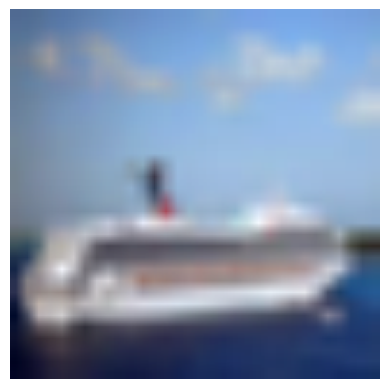

In [30]:
classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer','Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def plot_figure(image):
    plt.imshow(image.permute(1,2,0))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)

## Accuracy Evaluation Function

This function calculates classification accuracy by comparing model predictions to true labels. It uses `model.eval()` to disable dropout and sets `torch.no_grad()` to save memory during inference.

**How it works:**
1. Iterate through all batches in the data loader
2. Get model predictions (argmax of output scores)
3. Count correct predictions
4. Return accuracy as a percentage (0-1)

In [31]:
def accuracy(model, loader):

    # keep track of correct predictions and total examples
    num_correct = 0
    num_total = 0

    # put model in evaluation mode (disables dropout, batch‑norm updates, etc.)
    model.eval()

    # ensure model is on the right device before running
    model = model.to(device=device)

    with torch.no_grad():                    # no grad needed for inference
        for xi, yi in loader:                # iterate over batches from the loader
            
            # move inputs and labels to gpu
            xi = xi.to(device=device, dtype=torch.float32)   
            yi = yi.to(device=device, dtype=torch.long) 

            scores = model(xi)               # forward pass, calculates class scores for xi
            _, pred = scores.max(dim=1)      # predicted class is index of max score
            
            num_correct += (pred == yi).sum()    # count correct in this batch
            num_total += pred.size(0)            # add batch size to total
            
        return float(num_correct) / num_total     # return overall accuracy



## Training Loop Implementation

The training loop implements the standard deep learning workflow:

**Training process per epoch:**
1. **Forward pass**: Compute model predictions
2. **Loss calculation**: Use cross-entropy loss (appropriate for multi-class classification)
3. **Backward pass**: Compute gradients via backpropagation
4. **Optimization**: Update weights using Adam optimizer
5. **Validation**: Evaluate accuracy on validation set

In [32]:
def train(model, optimiser, epochs=100):
#     def train(model, optimiser, scheduler = None, epochs=100):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input= scores, target=yi)
        
            optimiser.zero_grad()           
            cost.backward()
            optimiser.step()           
            
        acc = accuracy(model, val_loader)
#         if epoch%5 == 0:     
        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')
#         scheduler.step()

## Model 1: ResNet18 (Baseline)

ResNet (Residual Network) was introduced by Microsoft Research in 2015 and won the ImageNet competition that year. It solved the "vanishing gradient problem" in very deep networks by introducing skip connections that allow gradients to flow directly through the network. ResNet18 is the 18-layer variant, balancing depth with computational efficiency.

#### Loading pretrained model

In [ ]:
# Load pre-trained ResNet18 model with ImageNet weights
model_resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


#### Exploring the model

In [ ]:
for i, w in enumerate(model_resnet18.parameters()):
    print(i, w.shape, w.requires_grad) # check which parameters require gradients (are trainable)

0 torch.Size([64, 3, 7, 7]) True
1 torch.Size([64]) True
2 torch.Size([64]) True
3 torch.Size([64, 64, 3, 3]) True
4 torch.Size([64]) True
5 torch.Size([64]) True
6 torch.Size([64, 64, 3, 3]) True
7 torch.Size([64]) True
8 torch.Size([64]) True
9 torch.Size([64, 64, 3, 3]) True
10 torch.Size([64]) True
11 torch.Size([64]) True
12 torch.Size([64, 64, 3, 3]) True
13 torch.Size([64]) True
14 torch.Size([64]) True
15 torch.Size([128, 64, 3, 3]) True
16 torch.Size([128]) True
17 torch.Size([128]) True
18 torch.Size([128, 128, 3, 3]) True
19 torch.Size([128]) True
20 torch.Size([128]) True
21 torch.Size([128, 64, 1, 1]) True
22 torch.Size([128]) True
23 torch.Size([128]) True
24 torch.Size([128, 128, 3, 3]) True
25 torch.Size([128]) True
26 torch.Size([128]) True
27 torch.Size([128, 128, 3, 3]) True
28 torch.Size([128]) True
29 torch.Size([128]) True
30 torch.Size([256, 128, 3, 3]) True
31 torch.Size([256]) True
32 torch.Size([256]) True
33 torch.Size([256, 256, 3, 3]) True
34 torch.Size([25

In [ ]:
 # print the architecture of the ResNet18 model
model_resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Ajustar a nuestro modelo

In [ ]:
# create a new sequential model that contains all layers of ResNet18
model_aux = nn.Sequential(*list(model_resnet18.children()))
model_aux

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
# create a new sequential model that contains all layers of ResNet18 except the last fully connected layer
model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])

In [ ]:
# print the architecture of the new model without the last fully connected layer 
model_aux 

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
# freeze the parameters of the new model so that they are not updated during training
for i, parameter in enumerate(model_aux.parameters()):
    parameter.requires_grad = False

In [ ]:
for i, parameter in enumerate(model_aux.parameters()):
    print(i, parameter.requires_grad) # check that all parameters are frozen (not trainable)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 False
33 False
34 False
35 False
36 False
37 False
38 False
39 False
40 False
41 False
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 False
51 False
52 False
53 False
54 False
55 False
56 False
57 False
58 False
59 False


In [ ]:
# define the new model by adding a new fully connected layer on top of the frozen ResNet18 layers

hidden1 = 256 
hidden = 256
lr = 5e-4
epochs = 3

# model1 = nn.Sequential(nn.Flatten(),
#                        nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
#                        nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
#                        nn.Linear(in_features=hidden, out_features=10))

model1 = nn.Sequential(model_aux, # add the frozen ResNet18 layers
                       nn.Flatten(), # flatten the output of ResNet18 to a vector
                       nn.Linear(in_features=512, out_features= 10, bias= True)) # add a new fully connected layer with 10 output classes (for CIFAR-10)



# create an Adam optimiser to update the parameters of the new model (only the last fully connected layer will be updated since the rest are frozen)
optimiser = torch.optim.Adam(model1.parameters(), lr=lr, betas=(0.9, 0.999))  


# train(model1, optimiser, epochs)

In [42]:
model1

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
# Train model
train(model1, optimiser, epochs)

Epoch: 0, costo: 0.8481226563453674, accuracy: 0.7692,
Epoch: 1, costo: 1.0532242059707642, accuracy: 0.7946,
Epoch: 2, costo: 0.3095748722553253, accuracy: 0.8018,


In [ ]:
# Evaluate model on test set
accuracy(model1, test_loader)

0.7978

## Model 2: AlexNet

AlexNet, created by Alex Krizhevsky in 2012, was the breakthrough model that sparked the deep learning revolution. It won the ImageNet competition with a massive margin (16% error vs 26% for the runner-up), proving that deep CNNs could outperform traditional computer vision methods. It was one of the first models to successfully use GPUs for training.

In [45]:
# Load pre-trained AlexNet model with ImageNet weights
alexnet = models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [46]:
alexnet # print the architecture of the AlexNet model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### Architecture Overview
- **Total layers**: 8 trainable layers
  - 5 convolutional layers (in `.features`)
  - 3 fully-connected layers (in `.classifier`)
- **Pre-trained on**: ImageNet (1.2M images, 1000 classes)
- **Key advantage**: Clean separation between `.features` (frozen) and `.classifier` (modified)

### Transfer Learning Strategy
1. **Freeze** all convolutional layers → Keep learned visual features
2. **Replace** final layer: `Linear(4096 → 1000)` becomes `Linear(4096 → 10)`
3. **Train** only the new output layer for CIFAR-10's 10 classes

This approach is simpler than ResNet18 because:
- No need to manually extract feature layers
- Direct access to `.classifier[-1]` for replacement
- Built-in flatten operation in the classifier

In [47]:

# Freeze all convolutional feature layers
# These learned features from ImageNet are still useful for CIFAR-10
for param in alexnet.features.parameters():
    param.requires_grad = False  # Don't update these weights during training

# Replace the final classifier layer for CIFAR-10
# AlexNet's classifier has 7 layers, we only replace the last one
in_features = alexnet.classifier[-1].in_features  # Get input size (4096)
alexnet.classifier[-1] = nn.Linear(in_features, 10)  # Replace: 4096 → 10 classes

#Move model to GPU
alexnet = alexnet.to(device)

# Setup optimizer - only trains unfrozen parameters (new classifier)
opt_alex = torch.optim.Adam(
                                filter(lambda p: p.requires_grad, alexnet.parameters()),  # Only trainable params
                                lr=5e-4)

# Train the model
train(alexnet, opt_alex, epochs=3)

# Evaluate on test set
print("AlexNet test acc:", accuracy(alexnet, test_loader))


Epoch: 0, costo: 0.45278680324554443, accuracy: 0.8294,
Epoch: 1, costo: 0.62282395362854, accuracy: 0.8322,
Epoch: 2, costo: 0.049782246351242065, accuracy: 0.8222,
AlexNet test acc: 0.816


##  Model 3: VGG16

VGG16 was developed by the Visual Geometry Group at Oxford University in 2014. It demonstrated that network depth is critical for good performance by using a very deep architecture with small 3×3 convolution filters throughout. VGG16's uniform architecture made it extremely popular for transfer learning, despite being computationally expensive.

In [48]:
# Load pre-trained VGG16 model with ImageNet weights
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [49]:
# print the architecture of the VGG16 model
vgg16 

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Architecture Overview
- **Layers**: 16 weight layers (13 convolutional + 3 fully connected)
- **Pre-trained on**: ImageNet
- **Characteristics**: Very deep, uniform architecture with small 3×3 filters

### Transfer Learning Strategy
Similar to AlexNet, VGG16 has:
- **`.features`**: Convolutional layers (frozen)
- **`.classifier`**: 3 fully-connected layers (last one replaced)



VGG16's modular design allows direct layer replacement without:
- Manual feature extraction (`[:-1]` slicing)
- Adding explicit `nn.Flatten()` layers
- Building new Sequential models from scratch


In [50]:


# Freeze convolutional base (feature extractor) - Keep the learned low-level features from ImageNet
for param in vgg16.features.parameters():
    param.requires_grad = False  # Freeze weights

# Replace final classifier layer for CIFAR-10
# VGG16's classifier ends with Linear(4096 → 1000). We replace it with Linear(4096 → 10)
in_features = vgg16.classifier[-1].in_features  # Get input size (4096)
vgg16.classifier[-1] = nn.Linear(in_features, 10)  # New layer for 10 classes

# Move model to GPU
vgg16 = vgg16.to(device)

# Setup optimizer - only optimizes the new classifier layer
opt_vgg = torch.optim.Adam(
                                filter(lambda p: p.requires_grad, vgg16.parameters()),  # Trainable params only
                                lr=5e-4
                            )
# Train the model
train(vgg16, opt_vgg, epochs=3)   

# Evaluate on test set
print("VGG16 test acc:", accuracy(vgg16, test_loader))


Epoch: 0, costo: 0.08336208760738373, accuracy: 0.8654,
Epoch: 1, costo: 0.14626634120941162, accuracy: 0.8562,
Epoch: 2, costo: 1.076580286026001, accuracy: 0.8712,
VGG16 test acc: 0.868


## Results Summary and Comparison

### Test Accuracy Performance

| Model | Test Accuracy | Training Epochs | Key Characteristics |
|-------|--------------|----------------|---------------------|
| ResNet18 | 79.78% | 3 | Skip connections, 18 layers |
| AlexNet | 81.6% | 3 | First deep CNN breakthrough (2012) |
| VGG16 | 86.8% | 3 | Deep uniform architecture, 16 layers |

### Key Findings

**VGG16 achieved the best performance (86.8%)** on CIFAR-10, outperforming both ResNet18 and AlexNet by significant margins. This demonstrates that:

1. **Architecture depth matters**: VGG16's deeper network (16 layers with 3×3 filters) captured more complex features despite being computationally expensive

2. **Transfer learning effectiveness**: All three pre-trained models achieved >79% accuracy with only 3 epochs of fine-tuning, showing that ImageNet features transfer well to CIFAR-10

3. **Model trade-offs**: While VGG16 performed best, ResNet18 offers better efficiency with its skip connections, and AlexNet provides a good balance between simplicity and performance

### Conclusion

Transfer learning proved highly effective for CIFAR-10 classification. By freezing pre-trained feature extractors and training only the final classifier layer, we achieved strong results quickly. VGG16's uniform deep architecture was most suitable for this task, achieving nearly 87% accuracy.


## References

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition* (pp. 770-778). https://doi.org/10.1109/CVPR.2016.90

Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. In F. Pereira, C. J. Burges, L. Bottou, & K. Q. Weinberger (Eds.), *Advances in Neural Information Processing Systems* (Vol. 25, pp. 1097-1105). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html

Simonyan, K., & Zisserman, A. (2015). Very deep convolutional networks for large-scale image recognition. In *Proceedings of the International Conference on Learning Representations* (ICLR). https://arxiv.org/abs/1409.1556
